# IDEA #7: Payment & Device Behaviour

Muc tieu: Phan tich moi lien he giua payment_method, device_type va cancel rate theo khung D-Di-P-Pr.

In [1]:
# Hiển thêm: install dependencies cho notebook (chạy 1 lần đầu — sau đó comment lại để tránh re-install)
%pip install -q numpy pandas matplotlib seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression

sns.set_theme(style='whitegrid')
np.random.seed(42)

cwd = Path.cwd()
DATA_DIR = None
for _ in range(6):
    candidate = cwd / 'data' / 'datathon-2026-round-1'
    if candidate.exists():
        DATA_DIR = candidate
        break
    cwd = cwd.parent

if DATA_DIR is None:
    raise FileNotFoundError('Khong tim thay thu muc data/datathon-2026-round-1')

OUTPUT_DIR = Path.cwd() / 'outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(f'Pandas: {pd.__version__}')
print(f'NumPy: {np.__version__}')
print(f'Data path: {DATA_DIR}')
print(f'Output path: {OUTPUT_DIR.resolve()}')

Pandas: 3.0.2
NumPy: 2.4.4
Data path: /Users/dominhhien/Documents/AI/Datathon/TuNgayToiGapEm/data/datathon-2026-round-1
Output path: /Users/dominhhien/Documents/AI/Datathon/TuNgayToiGapEm/phan_2_eda/outputs/idea_7/outputs


## CELL 2: Load du lieu

In [3]:
orders = pd.read_csv(DATA_DIR / 'orders.csv')
payments = pd.read_csv(DATA_DIR / 'payments.csv')

orders['order_date'] = pd.to_datetime(orders['order_date'])

print('Orders shape:', orders.shape)
print('Payments shape:', payments.shape)
print('Payment methods:', sorted(orders['payment_method'].dropna().unique().tolist()))
print('Device types:', sorted(orders['device_type'].dropna().unique().tolist()))

Orders shape: (646945, 8)
Payments shape: (646945, 4)
Payment methods: ['apple_pay', 'bank_transfer', 'cod', 'credit_card', 'paypal']
Device types: ['desktop', 'mobile', 'tablet']


## CELL 3: Tao fact table payment-device

In [4]:
orders_pay = orders.merge(payments[['order_id', 'payment_value', 'installments']], on='order_id', how='left')
orders_pay['is_cancelled'] = (orders_pay['order_status'] == 'cancelled').astype(int)

payment_summary = orders_pay.groupby('payment_method').agg(
    orders_count=('order_id', 'nunique'),
    cancelled_orders=('is_cancelled', 'sum'),
    avg_payment_value=('payment_value', 'mean'),
    avg_installments=('installments', 'mean')
).reset_index()
payment_summary['cancel_rate'] = payment_summary['cancelled_orders'] / payment_summary['orders_count']
payment_summary = payment_summary.sort_values('cancel_rate', ascending=False).reset_index(drop=True)

device_payment = orders_pay.groupby(['device_type', 'payment_method']).agg(
    orders_count=('order_id', 'nunique'),
    cancelled_orders=('is_cancelled', 'sum')
).reset_index()
device_payment['cancel_rate'] = np.where(device_payment['orders_count'] > 0, device_payment['cancelled_orders'] / device_payment['orders_count'], 0)

monthly_payment = orders_pay.copy()
monthly_payment['month'] = monthly_payment['order_date'].dt.to_period('M').dt.to_timestamp()
monthly_payment_summary = monthly_payment.groupby(['month', 'payment_method']).agg(
    orders_count=('order_id', 'nunique'),
    cancelled_orders=('is_cancelled', 'sum')
).reset_index()
monthly_payment_summary['cancel_rate'] = np.where(
    monthly_payment_summary['orders_count'] > 0,
    monthly_payment_summary['cancelled_orders'] / monthly_payment_summary['orders_count'],
    0
)

installment_summary = orders_pay.groupby('installments').agg(
    orders_count=('order_id', 'nunique'),
    avg_payment_value=('payment_value', 'mean'),
    cancel_rate=('is_cancelled', 'mean')
).reset_index().sort_values('installments')

print('Payment summary shape:', payment_summary.shape)
print('Device-payment table shape:', device_payment.shape)
print('Monthly payment table shape:', monthly_payment_summary.shape)

Payment summary shape: (5, 6)
Device-payment table shape: (15, 5)
Monthly payment table shape: (630, 5)


## CELL 4: TANG 1 - DESCRIPTIVE

In [5]:
print('='*72)
print('TANG 1: DESCRIPTIVE - PAYMENT & DEVICE OVERVIEW')
print('='*72)

total_orders = orders_pay['order_id'].nunique()
total_cancelled = int(orders_pay['is_cancelled'].sum())
overall_cancel_rate = total_cancelled / total_orders
overall_avg_payment = orders_pay['payment_value'].mean()

print(f'Tong orders: {total_orders:,.0f}')
print(f'Tong cancelled orders: {total_cancelled:,.0f}')
print(f'Overall cancel rate: {overall_cancel_rate:.2%}')
print(f'Average payment value: ${overall_avg_payment:,.2f}')

print('\nCancel rate theo payment method:')
for _, r in payment_summary.iterrows():
    print(f"- {r['payment_method']:15} | cancel_rate={r['cancel_rate']:.2%} | orders={r['orders_count']:>8,.0f} | avg_payment=${r['avg_payment_value']:>10,.2f}")

TANG 1: DESCRIPTIVE - PAYMENT & DEVICE OVERVIEW
Tong orders: 646,945
Tong cancelled orders: 59,462
Overall cancel rate: 9.19%
Average payment value: $24,238.33

Cancel rate theo payment method:
- cod             | cancel_rate=16.00% | orders=  96,681 | avg_payment=$ 24,275.17
- paypal          | cancel_rate=8.06% | orders=  97,018 | avg_payment=$ 24,363.32
- apple_pay       | cancel_rate=8.01% | orders=  64,763 | avg_payment=$ 24,153.75
- credit_card     | cancel_rate=7.98% | orders= 356,352 | avg_payment=$ 24,217.82
- bank_transfer   | cancel_rate=7.89% | orders=  32,131 | avg_payment=$ 24,148.10


## CELL 5: TANG 2 - DIAGNOSTIC

In [6]:
print('='*72)
print('TANG 2: DIAGNOSTIC - COD RISK VA DEVICE PATTERN')
print('='*72)

highest_cancel = payment_summary.loc[payment_summary['cancel_rate'].idxmax()]
lowest_cancel = payment_summary.loc[payment_summary['cancel_rate'].idxmin()]

print(f"Payment co cancel rate cao nhat: {highest_cancel['payment_method']} ({highest_cancel['cancel_rate']:.2%})")
print(f"Payment co cancel rate thap nhat: {lowest_cancel['payment_method']} ({lowest_cancel['cancel_rate']:.2%})")
print(f"Khoang cach: {(highest_cancel['cancel_rate'] - lowest_cancel['cancel_rate'])*100:.2f} pp")

pivot_device = device_payment.pivot(index='device_type', columns='payment_method', values='cancel_rate').fillna(0)
worst_cell = device_payment.loc[device_payment['cancel_rate'].idxmax()]
best_cell = device_payment.loc[device_payment['cancel_rate'].idxmin()]

print(f"Rui ro cao nhat theo o device-payment: {worst_cell['device_type']} x {worst_cell['payment_method']} ({worst_cell['cancel_rate']:.2%})")
print(f"Tot nhat theo o device-payment: {best_cell['device_type']} x {best_cell['payment_method']} ({best_cell['cancel_rate']:.2%})")

payment_summary['risk_score'] = payment_summary['cancel_rate'] * np.log1p(payment_summary['orders_count'])
risk_top = payment_summary.sort_values('risk_score', ascending=False).iloc[0]
print(f"Risk score cao nhat: {risk_top['payment_method']} ({risk_top['risk_score']:.3f})")

TANG 2: DIAGNOSTIC - COD RISK VA DEVICE PATTERN
Payment co cancel rate cao nhat: cod (16.00%)
Payment co cancel rate thap nhat: bank_transfer (7.89%)
Khoang cach: 8.11 pp
Rui ro cao nhat theo o device-payment: tablet x cod (16.93%)
Tot nhat theo o device-payment: mobile x bank_transfer (7.77%)
Risk score cao nhat: cod (1.837)


## CELL 6: TANG 3 - PREDICTIVE

In [7]:
top_risk_payment = payment_summary.sort_values('cancel_rate', ascending=False).iloc[0]['payment_method']
pay_month = monthly_payment_summary[monthly_payment_summary['payment_method'] == top_risk_payment].sort_values('month').reset_index(drop=True)

X = np.arange(len(pay_month)).reshape(-1, 1)
y = pay_month['cancel_rate'].values
model = LinearRegression()
model.fit(X, y)

future_X = np.arange(len(pay_month), len(pay_month) + 3).reshape(-1, 1)
forecast_cancel = model.predict(future_X)
trend_slope = model.coef_[0]

print('='*72)
print('TANG 3: PREDICTIVE - FORECAST CANCEL RATE')
print('='*72)
print(f'Payment method duoc du bao: {top_risk_payment}')
print(f'Cancel rate hien tai: {pay_month.iloc[-1]["cancel_rate"]:.2%}')
print(f'Forecast +1M: {forecast_cancel[0]:.2%}')
print(f'Forecast +2M: {forecast_cancel[1]:.2%}')
print(f'Forecast +3M: {forecast_cancel[2]:.2%}')
print(f'Trend slope: {trend_slope*100:.4f} pp/thang')

TANG 3: PREDICTIVE - FORECAST CANCEL RATE
Payment method duoc du bao: cod
Cancel rate hien tai: 14.09%
Forecast +1M: 15.93%
Forecast +2M: 15.93%
Forecast +3M: 15.93%
Trend slope: 0.0004 pp/thang


## CELL 7: CHART 1 - Cancel rate theo payment method

/var/folders/bv/4w30k8fj1ls_zjsxx60rw_nw0000gn/T/ipykernel_87351/3543791394.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=plot1, x='cancel_rate', y='payment_method', palette='magma')


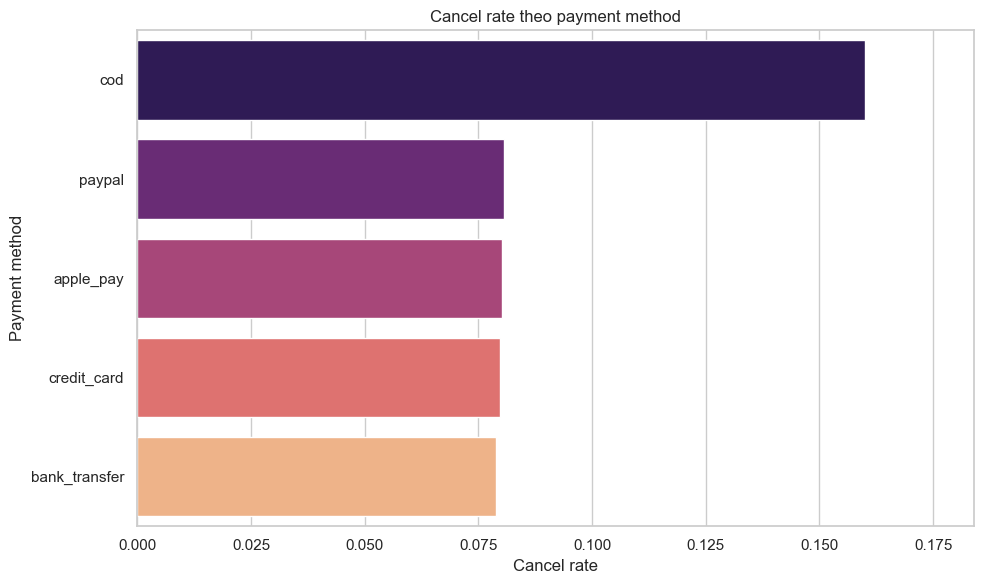

Saved: 01_cancel_rate_by_payment_method.png


In [8]:
plot1 = payment_summary.sort_values('cancel_rate', ascending=False).copy()
plt.figure(figsize=(10, 6))
sns.barplot(data=plot1, x='cancel_rate', y='payment_method', palette='magma')
plt.title('Cancel rate theo payment method')
plt.xlabel('Cancel rate')
plt.ylabel('Payment method')
plt.xlim(0, max(plot1['cancel_rate'].max() * 1.15, 0.01))
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '01_cancel_rate_by_payment_method.png', dpi=200)
plt.show()
print('Saved: 01_cancel_rate_by_payment_method.png')

## CELL 8: CHART 2 - Heatmap device x payment

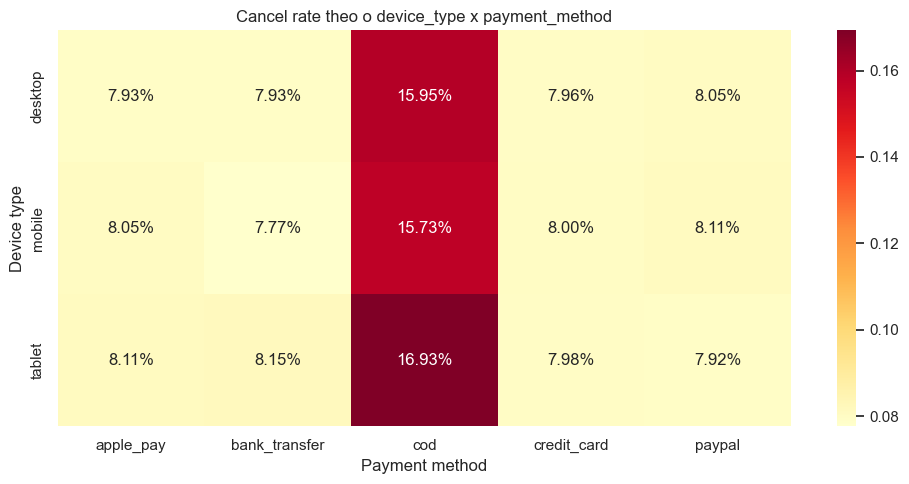

Saved: 02_device_payment_cancel_heatmap.png


In [9]:
heat = device_payment.pivot(index='device_type', columns='payment_method', values='cancel_rate').fillna(0)
plt.figure(figsize=(10, 5))
sns.heatmap(heat, annot=True, fmt='.2%', cmap='YlOrRd')
plt.title('Cancel rate theo o device_type x payment_method')
plt.xlabel('Payment method')
plt.ylabel('Device type')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '02_device_payment_cancel_heatmap.png', dpi=200)
plt.show()
print('Saved: 02_device_payment_cancel_heatmap.png')

## CELL 9: CHART 3 - Monthly cancel trend cua payment rui ro cao

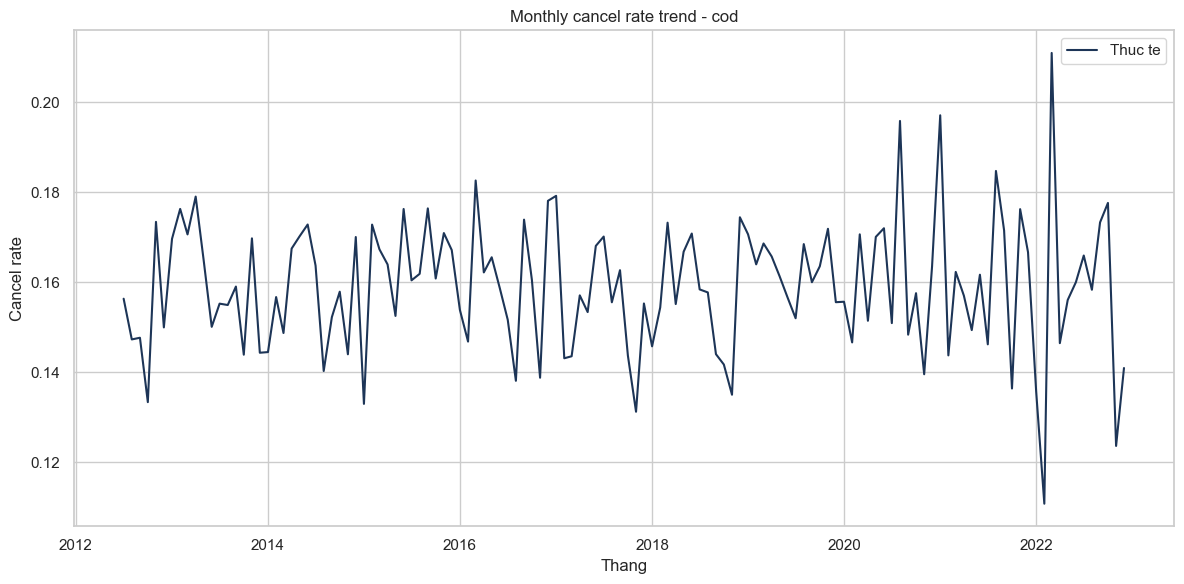

Saved: 03_top_risk_payment_cancel_trend.png


In [10]:
plt.figure(figsize=(12, 6))
plt.plot(pay_month['month'], pay_month['cancel_rate'], label='Thuc te', color='#1d3557')
plt.title(f'Monthly cancel rate trend - {top_risk_payment}')
plt.xlabel('Thang')
plt.ylabel('Cancel rate')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '03_top_risk_payment_cancel_trend.png', dpi=200)
plt.show()
print('Saved: 03_top_risk_payment_cancel_trend.png')

## CELL 10: CHART 4 - Installment vs avg payment value

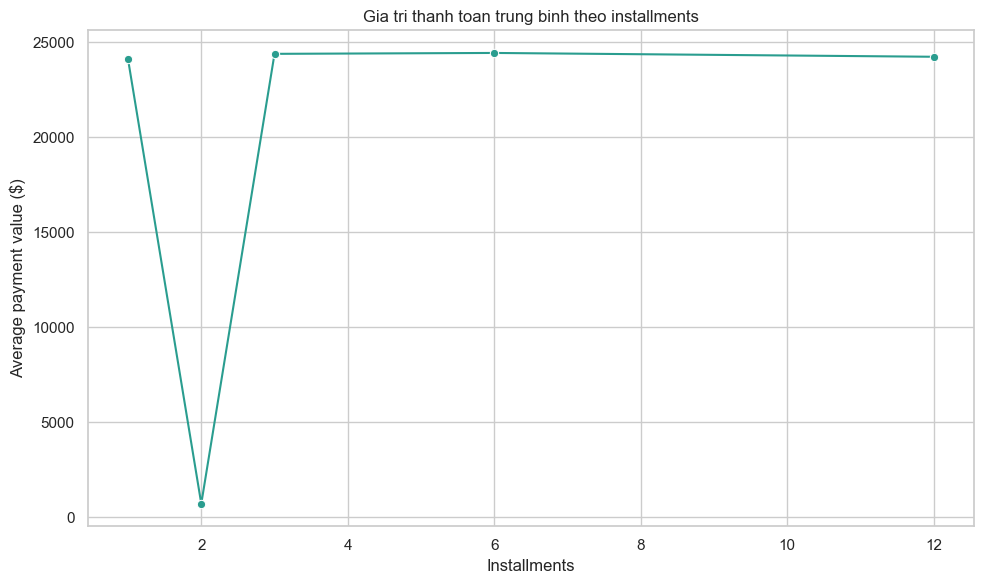

Saved: 04_installment_avg_payment_value.png


In [11]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=installment_summary, x='installments', y='avg_payment_value', marker='o', color='#2a9d8f')
plt.title('Gia tri thanh toan trung binh theo installments')
plt.xlabel('Installments')
plt.ylabel('Average payment value ($)')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / '04_installment_avg_payment_value.png', dpi=200)
plt.show()
print('Saved: 04_installment_avg_payment_value.png')

## CELL 11: TANG 4 - PRESCRIPTIVE

In [12]:
print('='*72)
print('TANG 4: PRESCRIPTIVE - HANH DONG TOI UU PAYMENT FLOW')
print('='*72)

cod_row = payment_summary[payment_summary['payment_method'].str.lower() == 'cod']
if len(cod_row) > 0:
    cod_cancel = float(cod_row.iloc[0]['cancel_rate'])
    cod_orders = float(cod_row.iloc[0]['orders_count'])
    target_cancel = max(cod_cancel - 0.05, 0)
    saved_orders = cod_orders * (cod_cancel - target_cancel)
    est_reclaim = saved_orders * overall_avg_payment
else:
    cod_cancel = np.nan
    target_cancel = np.nan
    saved_orders = 0
    est_reclaim = 0

print('1) COD optimization:')
print(f'- Cancel rate COD hien tai: {cod_cancel:.2%}' if pd.notna(cod_cancel) else '- Khong tim thay COD trong data')
print(f'- Muc tieu giam 5pp: {target_cancel:.2%}' if pd.notna(target_cancel) else '- Khong co muc tieu do khong tim thay COD')
print(f'- So don co the giu lai uoc tinh: {saved_orders:,.0f}')
print(f'- Gia tri doanh thu giu lai uoc tinh: ${est_reclaim:,.0f}')

print('2) Device-specific intervention: uu tien o device-payment co cancel cao nhat')
print(f"- O rui ro cao nhat: {worst_cell['device_type']} x {worst_cell['payment_method']} ({worst_cell['cancel_rate']:.2%})")
print('3) Khuyen khich prepaid 2% cho nhom khach COD da mua >=1 lan')
print('4) Theo doi scorecard: cancel_rate theo payment, device, va cohort moi/thang')

TANG 4: PRESCRIPTIVE - HANH DONG TOI UU PAYMENT FLOW
1) COD optimization:
- Cancel rate COD hien tai: 16.00%
- Muc tieu giam 5pp: 11.00%
- So don co the giu lai uoc tinh: 4,834
- Gia tri doanh thu giu lai uoc tinh: $117,169,321
2) Device-specific intervention: uu tien o device-payment co cancel cao nhat
- O rui ro cao nhat: tablet x cod (16.93%)
3) Khuyen khich prepaid 2% cho nhom khach COD da mua >=1 lan
4) Theo doi scorecard: cancel_rate theo payment, device, va cohort moi/thang


## CELL 12: Export summary metrics

In [13]:
best_installment = installment_summary.loc[installment_summary['avg_payment_value'].idxmax()]

summary_metrics = pd.DataFrame({
    'Metric': [
        'Total Orders',
        'Total Cancelled Orders',
        'Overall Cancel Rate',
        'Average Payment Value',
        'Number of Payment Methods',
        'Top Risk Payment Method',
        'Top Risk Cancel Rate',
        'Lowest Risk Payment Method',
        'Lowest Risk Cancel Rate',
        'Cancel Rate Gap (pp)',
        'Highest Risk Device-Payment Cell',
        'Highest Risk Cell Cancel Rate',
        'Best Installment Plan',
        'Best Installment Avg Payment',
        'Forecast Top Risk Cancel (+1M)',
        'Top Risk Cancel Trend Slope (pp/month)',
        'COD Current Cancel Rate',
        'COD Target Cancel Rate',
        'Estimated Saved Orders',
        'Estimated Reclaimed Revenue'
    ],
    'Value': [
        f"{total_orders:,.0f}",
        f"{total_cancelled:,.0f}",
        f"{overall_cancel_rate:.2%}",
        f"${overall_avg_payment:,.2f}",
        f"{payment_summary['payment_method'].nunique()}",
        str(highest_cancel['payment_method']),
        f"{highest_cancel['cancel_rate']:.2%}",
        str(lowest_cancel['payment_method']),
        f"{lowest_cancel['cancel_rate']:.2%}",
        f"{(highest_cancel['cancel_rate'] - lowest_cancel['cancel_rate'])*100:.2f}",
        f"{worst_cell['device_type']} x {worst_cell['payment_method']}",
        f"{worst_cell['cancel_rate']:.2%}",
        f"{int(best_installment['installments'])}",
        f"${best_installment['avg_payment_value']:,.2f}",
        f"{forecast_cancel[0]:.2%}",
        f"{trend_slope*100:.4f}",
        f"{cod_cancel:.2%}" if pd.notna(cod_cancel) else 'N/A',
        f"{target_cancel:.2%}" if pd.notna(target_cancel) else 'N/A',
        f"{saved_orders:,.0f}",
        f"${est_reclaim:,.0f}"
    ]
})

summary_metrics.to_csv(OUTPUT_DIR / 'summary_metrics.csv', index=False)
print(summary_metrics.to_string(index=False))
print('\nSaved: summary_metrics.csv')

                                Metric         Value
                          Total Orders       646,945
                Total Cancelled Orders        59,462
                   Overall Cancel Rate         9.19%
                 Average Payment Value    $24,238.33
             Number of Payment Methods             5
               Top Risk Payment Method           cod
                  Top Risk Cancel Rate        16.00%
            Lowest Risk Payment Method bank_transfer
               Lowest Risk Cancel Rate         7.89%
                  Cancel Rate Gap (pp)          8.11
      Highest Risk Device-Payment Cell  tablet x cod
         Highest Risk Cell Cancel Rate        16.93%
                 Best Installment Plan             6
          Best Installment Avg Payment    $24,446.65
        Forecast Top Risk Cancel (+1M)        15.93%
Top Risk Cancel Trend Slope (pp/month)        0.0004
               COD Current Cancel Rate        16.00%
                COD Target Cancel Rate        

## CELL 13: Ket luan

In [14]:
print('='*72)
print('ANALYSIS COMPLETE - IDEA #7 PAYMENT & DEVICE BEHAVIOUR')
print('='*72)
print('One-liner: COD khong chi la payment method; do la bai toan niem tin va van toc giao hang.')
print('Da tao 4 bieu do + summary_metrics.csv trong thu muc outputs.')

ANALYSIS COMPLETE - IDEA #7 PAYMENT & DEVICE BEHAVIOUR
One-liner: COD khong chi la payment method; do la bai toan niem tin va van toc giao hang.
Da tao 4 bieu do + summary_metrics.csv trong thu muc outputs.
